## Sensitivity Analsysis Code 
Sensitivity analysis using Morris screening (for our adapted version of the model from the paper). Trying to identify 6-7 parameters that we could focus on fitting accurately - those that have the greatest effect on the system.

In [1]:
# !pip install SALib
# import SALib

In [2]:
# need to deifne the ODE model 
import numpy as np
from scipy.integrate import solve_ivp

In [3]:

def ode_system(t, y, params):
    # parameters
    lambda_C,  eta_8, eta_N, d_C, lambda_DC_comb, d_D, sigma_N, \
    d_N, gamma_N, a_C, beta_2, d_Treg, lambda_Tr_comb, d_T8, lambda_T8_comb, K_Treg, K_D = params

    
    # state variables
    C, D, N, Tr, T8 = y

    # equations
    dCdt = lambda_C*C*(1-C/0.8) - eta_8*T8*C - eta_N*N*C - d_C*C
    dDdt = lambda_DC_comb*(C/(0.4 +C)) - d_D*D
    # the term lambda_DC*D_0 represents cancer cell induced DC recruitment so will increased with UV/Apobec treatment becuase increased mutations
    dNdt = sigma_N - d_N*N - gamma_N*Tr*N + a_C*N*(C/(1+C/0.4+N/beta_2))
    dTrdt = -d_Treg*Tr + lambda_Tr_comb*(C/(0.4+C))
    dT8dt = -d_T8*T8 + lambda_T8_comb*(D/(K_D+D))*(1/(1+Tr/K_Treg)) 
    # the term lambda_T8*T80 represents T8 activation and therefore will be changed depending on ICI treatment or not 

    return [dCdt, dDdt, dNdt, dTrdt, dT8dt]

def simulate(params):
    y0 = [0.8, 0.0, 0.0, 0.0, 0.0] # initial conditions
    t_eval = np.linspace(0, 14, 200) # the time that we are looking at is 0-14 for 200 evenly spaced time points
    sol = solve_ivp(lambda t, y: ode_system(t, y, params),
                    [0, 14], y0, t_eval=t_eval) # return the solution matrix
    return sol.y


In [4]:
from SALib.sample import morris, saltelli
from SALib.analyze import morris as morris_analyze
from SALib.analyze import sobol

# defining the baseline parameters from the paper 
baseline_params = {
   'lambda_C' : 1.5,
   # 'C_M' : 0.8,
   'eta_8' : 328.55, 
   'eta_N' : 300,
   'd_C' : 0.17,
   'lambda_DC_comb' : 8e-5,
   # 'K_C' : 0.4,
   'd_D' : 0.1,
   'sigma_N' : 5e-5,
   'd_N' : 0.1,
   'gamma_N' : 150,
   'a_C' : 0.5,
   # 'beta_1' : 0.4,
   'beta_2' : 2e-4,
   'd_Treg' : 0.2,
   'lambda_Tr_comb' : 2e-4,
   'd_T8' : 0.18,
   'lambda_T8_comb' : 0.00108,
   'K_Treg' : 2.5e-4,
   'K_D' : 4
}
#KPB25L
baseline_params = {'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.005, 'K_C': 0.4, 'd_D': 1.0, 'sigma_N': 0.0005, 'd_N': 0.5, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.01, 'lambda_T8_comb': 0.0002, 'K_Tr': 0.01, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
#T11
baseline_params = {'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.003, 'K_C': 0.4, 'd_D': 0.3, 'sigma_N': 0.0005, 'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.001, 'lambda_T8_comb': 0.0005, 'K_Tr': 0.0001, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
#T11 no t no mut
baseline_params = {'lambda_C': 2.0, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 'lambda_DC_comb': 0.0095, 'K_C': 0.4, 'd_D': 0.3, 'sigma_N': 0.0005, 'd_N': 0.13, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 'd_Tr': 0.2, 'lambda_Tr_comb': 0.00025, 'd_T8': 0.001, 'lambda_T8_comb': 3e-06, 'K_Tr': 0.0001, 'K_D': 0.0004, 'C_init': 0.8, 'D_init': 0.0, 'N_init': 0.0, 'Tr_init': 0.0, 'T8_init': 0.0}
pop_keys = ['C_M','K_C','beta_1','C_init','D_init','N_init','Tr_init','T8_init']
for key in pop_keys:
    baseline_params.pop(key,None)

# defining bounds of sampling as +/- 10% of what the paper has used 
names = list(baseline_params.keys())
values = list(baseline_params.values())
print(values)
bounds = [
    [0.9 * v, 1.1 * v]   # ±10% bounds
    for v in values
]

# define the SALib problem dictionary 
problem = {
    'num_vars': 17, # i have 23 parameters 
    'names': ['lambda_C','eta_8','eta_N', 'd_C','lambda_DC_comb','d_D','sigma_N','d_N','gamma_N','a_C','beta_2','d_Treg','lambda_Tr_comb','d_T8','lambda_T8_comb','K_Treg','K_D' ],
    'bounds': bounds   # sampling bounds for each parameter
    
}


[2.0, 328.25, 300, 0.17, 0.003, 0.3, 0.0005, 0.13, 150, 0.5, 0.0002, 0.2, 0.0003, 0.001, 0.0005, 0.0001, 0.0004]


In [5]:
# morris screening 
# generating samples 
param_values = morris.sample(problem, N=1000, num_levels=6) #1000 trajectories and each parameter can take 6 discrete values 
# choose a scalar output to analyse sensitivity on 

def model_output(params):
    C, D, N, Tr, T8 = simulate(params)

    day7_index = 100  # corresponds to t ≈ 7 days

    C_day7 = C[day7_index]
    # NK_day7  = N[day7_index]

    # Cancer at day 7
    return C_day7


Y = np.array([model_output(p) for p in param_values])


In [6]:
from SALib.sample.morris import sample
from SALib.analyze.morris import analyze

In [7]:
# analyse 
Si = analyze(problem, param_values, Y, conf_level=0.95)

In [8]:
# results
print("Parameter ranking by mean absolute effect:")
ranking = sorted(zip(problem['names'], Si['mu_star']), key=lambda x: -x[1])
for name, score in ranking:
    print(f"{name}: {score:.4f}")


Parameter ranking by mean absolute effect:
lambda_C: 0.0593
eta_N: 0.0387
sigma_N: 0.0367
lambda_Tr_comb: 0.0168
lambda_T8_comb: 0.0138
eta_8: 0.0137
d_N: 0.0125
d_C: 0.0121
K_Treg: 0.0096
gamma_N: 0.0072
d_Treg: 0.0055
a_C: 0.0027
K_D: 0.0024
lambda_DC_comb: 0.0024
beta_2: 0.0019
d_D: 0.0005
d_T8: 0.0001


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_morris_sorted(problem, Si, color_map):
    """
    problem: SALib problem dict (contains 'names')
    Si: Morris sensitivity results (contains 'mu_star')
    color_map: dict mapping parameter names -> colour strings
               e.g. {'p1': 'lightblue', 'p2': 'lightpink', ...}
    """

    names = np.array(problem['names'])
    mu_star = np.array(Si['mu_star'])

    # ---- Sort parameters by importance (descending) ----
    sort_idx = np.argsort(-mu_star)
    names_sorted = names[sort_idx]
    mu_sorted = mu_star[sort_idx]

    # ---- Assign colours based on user-defined mapping ----
    colors_sorted = [color_map.get(name, 'lightgrey') for name in names_sorted]

    # add legend 
    # ---- Build legend entries ----
    unique_colours = {}
    for name, colour in color_map.items():
        if colour not in unique_colours:
            unique_colours[colour] = []
        unique_colours[colour].append(name)

    labels = ['cancer params', 'DC params', 'NK params', 'Treg params','CD8+ params']
    legend_handles = [
        Patch(facecolor=colour, label=", ".join(params))
        for colour, params in unique_colours.items()
    ]
    # ---- Plot ----
    plt.figure(figsize=(10, 8))
    plt.barh(names_sorted, mu_sorted, color=colors_sorted)
    plt.gca().invert_yaxis()  # highest at the top

    plt.xlabel("Morris μ* (importance)")
    plt.title("Global Sensitivity Ranking (Morris Screening)")
    plt.legend(handles=legend_handles, title="Parameter Groups", loc="lower right")

    plt.tight_layout()
    plt.show()


color_map = {}

# pastel colours
colA = "lightblue" # cancer related params
colB = "mistyrose" # DC related params 
colC = "lavender" # NK related params
colD = "honeydew" # Treg related params
colE = "lemonchiffon" # CD8 related params 

# assign parameters to colours
for p in ["lambda_C", "d_C"]:
    color_map[p] = colA

for p in ["lambda_DC_comb", "d_D"]:
    color_map[p] = colB

for p in ["eta_N", "sigma_N", "d_N", "a_C", "beta_2", "gamma_N"]:
    color_map[p] = colC

for p in [ "d_Treg", "lambda_Tr_comb"]:
    color_map[p] = colD

for p in ["eta_8", "d_T8", "lambda_T8_comb", "K_Treg", "K_D"]:
    color_map[p] = colE
# any parameter not listed will default to grey

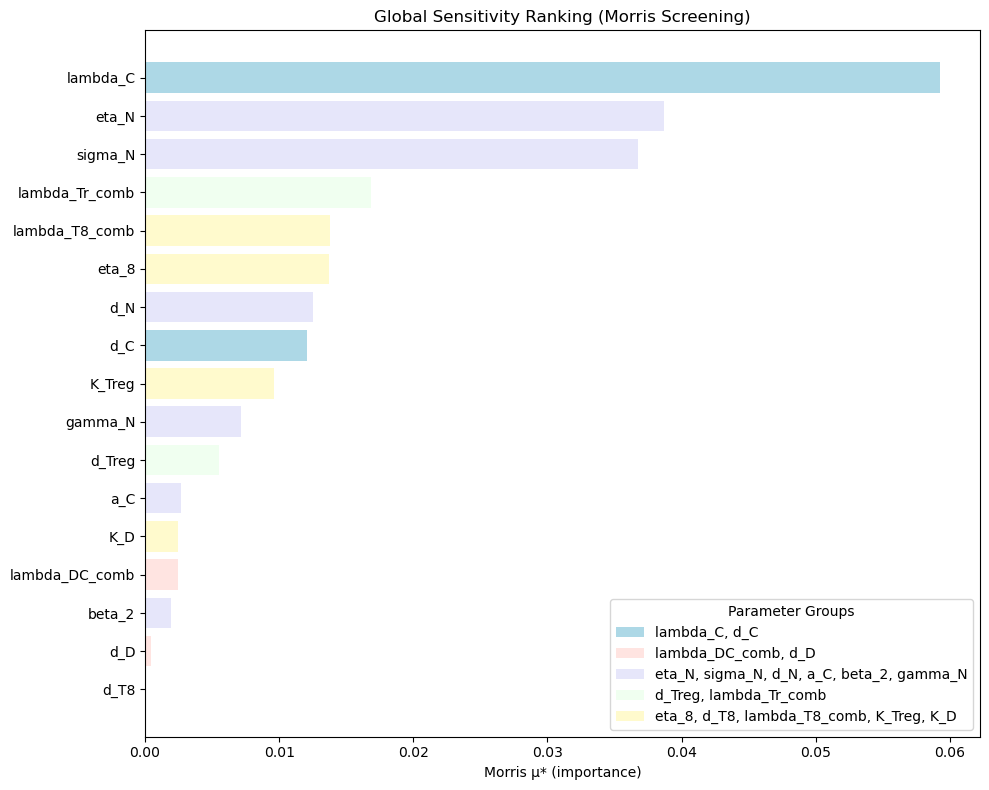

In [11]:
#T11 no ICI no mut
plot_morris_sorted(problem, Si, color_map)

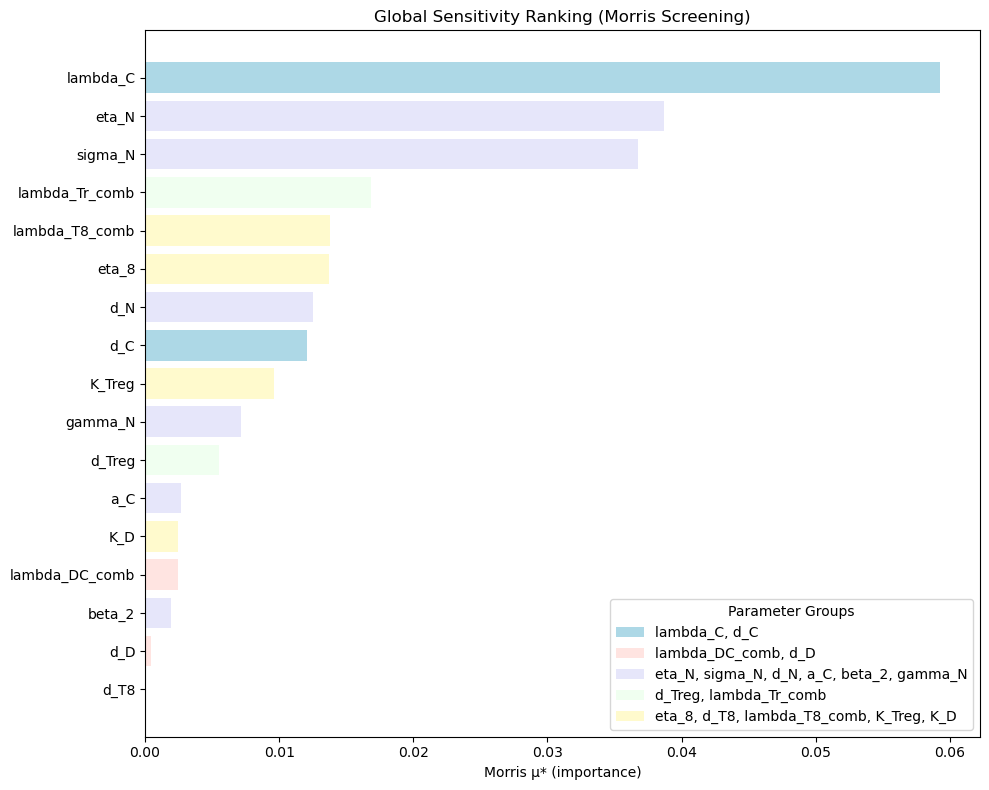

In [10]:
# T11 ICI mut
plot_morris_sorted(problem, Si, color_map)

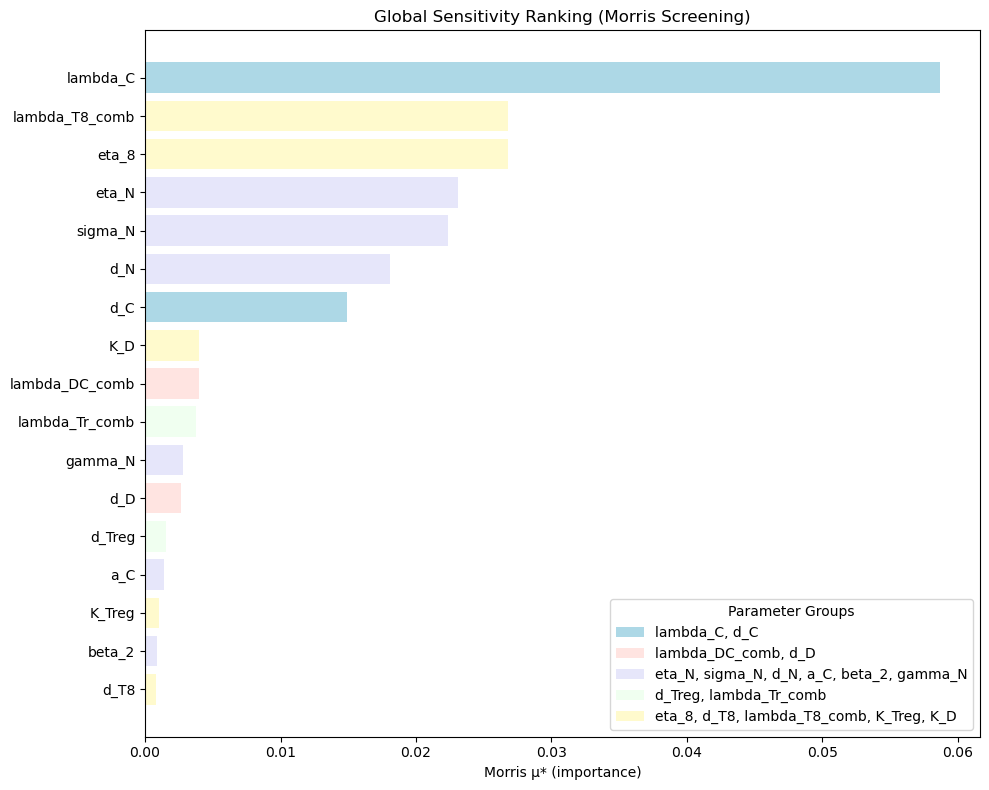

In [59]:
plot_morris_sorted(problem, Si, color_map)

## Sobol sensitvity analysis
Then if you have time do a sobol sensitvity analysis on the best few parameters identified from Morris - because Sobol is more accurate but takes more time 

In [104]:
param_order = [
    'lambda_C', 'eta_8', 'eta_N', 'd_C',
    'lambda_DC_comb', 'd_D', 'sigma_N', 'd_N',
    'gamma_N', 'a_C', 'beta_2', 'd_Treg',
    'lambda_Tr_comb', 'd_T8', 'lambda_T8_comb', 'K_Treg', 'K_D'
]

baseline_vector = np.array([baseline_params[key] for key in param_order])
bounds_vector   = np.array([bounds[i] for i in range(len(param_order))])


In [105]:
len(baseline_vector) == 20


True

In [106]:
selected = ['d_T8', 'lambda_T8_comb', 'sigma_N', 'K_Treg', 'd_N', 'gamma_N', 'K_D', 'a_C', 'C_M', 'lambda_DC_comb']


In [107]:
index_map = {name: i for i, name in enumerate(param_order)}
selected_indices = [index_map[p] for p in selected]
selected_bounds = [bounds_vector[i].tolist() for i in selected_indices]

In [108]:

sobol_problem = {
    'num_vars': len(selected),
    'names': selected,
    'bounds': selected_bounds
}


In [109]:
from SALib.sample import sobol
param_values = sobol.sample(sobol_problem, N=512, calc_second_order=True)


In [112]:
def model_output(sampled_params):
    full_params = baseline_vector.copy()

    for value, idx in zip(sampled_params, selected_indices):
        full_params[idx] = value

    C, D, N, Tr, T8 = simulate(full_params)
    day7_index = 100
    

    return T8[day7_index] / (N[day7_index] + 1e-6)
    return T8[100]   # example output


In [113]:
Y = np.array([model_output(p) for p in param_values])


In [114]:
from SALib.analyze import sobol
Si = sobol.analyze(sobol_problem, Y, calc_second_order=True)


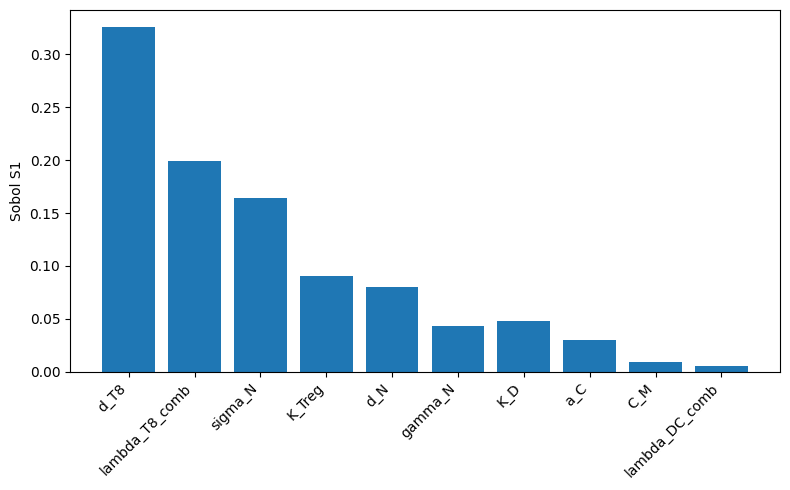

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(sobol_problem['names'], Si['S1'])
plt.ylabel("Sobol S1")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
